# Australian NEM Operational Demand Reversal — Descriptive Findings

Behind-the-meter rooftop PV has progressively inverted the historic shape of daily demand in the Australian National Electricity Market. Where the system was once max-demand-constrained (afternoon air-conditioning peak), several regions now see their *lowest* operational demand in the middle of the day, when rooftop solar output is highest.

This notebook contains **Findings 1–3** — the descriptive evidence for how often, how deep, and where the reversal is occurring. Findings 4–8 (mechanism attribution + 24h-ahead ML classifier) are in [`02_reversal_classifier.ipynb`](./02_reversal_classifier.ipynb).

**Window:** 2022-08-01 → 2026-03-31 (44 months × 5 NEM regions ≈ 1.93 M five-minute intervals).

**Pre-registered hypotheses, thresholds and verdicts:** [docs/METHODOLOGY.md](../docs/METHODOLOGY.md).


## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Project root = parent of notebooks/
PROJECT_ROOT = Path('..').resolve()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

load_dotenv(PROJECT_ROOT / '.env')
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PWD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)


sns.set_style('whitegrid')
plt.rcParams['figure.dpi']       = 140
plt.rcParams['savefig.dpi']      = 140
plt.rcParams['figure.figsize']   = (11, 5)
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.labelsize']   = 11
plt.rcParams['legend.fontsize']  = 10
plt.rcParams['xtick.labelsize']  = 10
plt.rcParams['ytick.labelsize']  = 10

REGION_ORDER = ['SA1', 'VIC1', 'NSW1', 'QLD1', 'TAS1']


REGION_COLORS = {
    'SA1':  '#E45756',  # red    
    'VIC1': '#4C78A8',  # blue   
    'NSW1': '#54A24B',  # green
    'QLD1': '#F2A93B',  # amber
    'TAS1': '#9D9D9D',  # gray   
}

REGION_SHORT = {'SA1': 'SA', 'VIC1': 'VIC', 'NSW1': 'NSW', 'QLD1': 'QLD', 'TAS1': 'TAS'}
REGION_LONG  = {'SA1': 'South Australia', 'VIC1': 'Victoria',
                'NSW1': 'New South Wales', 'QLD1': 'Queensland', 'TAS1': 'Tasmania'}

In [2]:
# Connection sanity
pd.read_sql("""
SELECT regionid,
       COUNT(*) AS n_intervals,
       MIN(settlementdate) AS min_sd,
       MAX(settlementdate) AS max_sd
FROM raw.region_5min
GROUP BY 1 ORDER BY 1;
""", engine)

,regionid,n_intervals,min_sd,max_sd
0,NSW1,385632,2022-08-01 00:05:00,2026-04-01
1,QLD1,385632,2022-08-01 00:05:00,2026-04-01
2,SA1,385632,2022-08-01 00:05:00,2026-04-01
3,TAS1,385632,2022-08-01 00:05:00,2026-04-01
4,VIC1,385632,2022-08-01 00:05:00,2026-04-01


## Finding 1 — South Australia's midday reversal is now near-universal

**The question.** South Australia installed rooftop PV faster than anywhere else in the NEM (~45 % of households). Did that push the daily minimum demand from pre-dawn into the middle of the day — and if so, how often, and how deep?

**The analysis.** Compute SA's monthly reversal frequency (share of trading days whose lowest demand falls in hours 10–15) and the deepest daily minimum across 44 months.

**The finding.** SA reverses on **92 % of trading days on average** (std 7 pp, range 60–100 %) — the frequency has been near-saturated since the project window begins. The *magnitude* leg is still moving though: the deepest monthly minimum dropped from +120 MW in 2022 to **−311 MW** in late 2025 (i.e. SA now *exports* power at midday on some days). Frequency has hit a ceiling; growth now shows up in how deep the trough is.

In [3]:
sa = pd.read_sql("""
SELECT month,
       n_trading_days,
       n_reversal_days,
       reversal_pct,
       deepest_min_demand
FROM analytics.v_monthly_reversal_rate
WHERE regionid = 'SA1'
ORDER BY month;
""", engine, parse_dates=['month'])

summary = {
    'months': len(sa),
    'mean_pct': sa.reversal_pct.mean(),
    'std_pct':  sa.reversal_pct.std(),
    'min_pct':  sa.reversal_pct.min(),
    'max_pct':  sa.reversal_pct.max(),
    'min_pct_month': sa.loc[sa.reversal_pct.idxmin(), 'month'].strftime('%Y-%m'),
}
for k, v in summary.items():
    print(f'{k:>16}: {v}')

          months: 44
        mean_pct: 92.42931818181818
         std_pct: 7.161944129240286
         min_pct: 60.0
         max_pct: 100.0
   min_pct_month: 2024-06


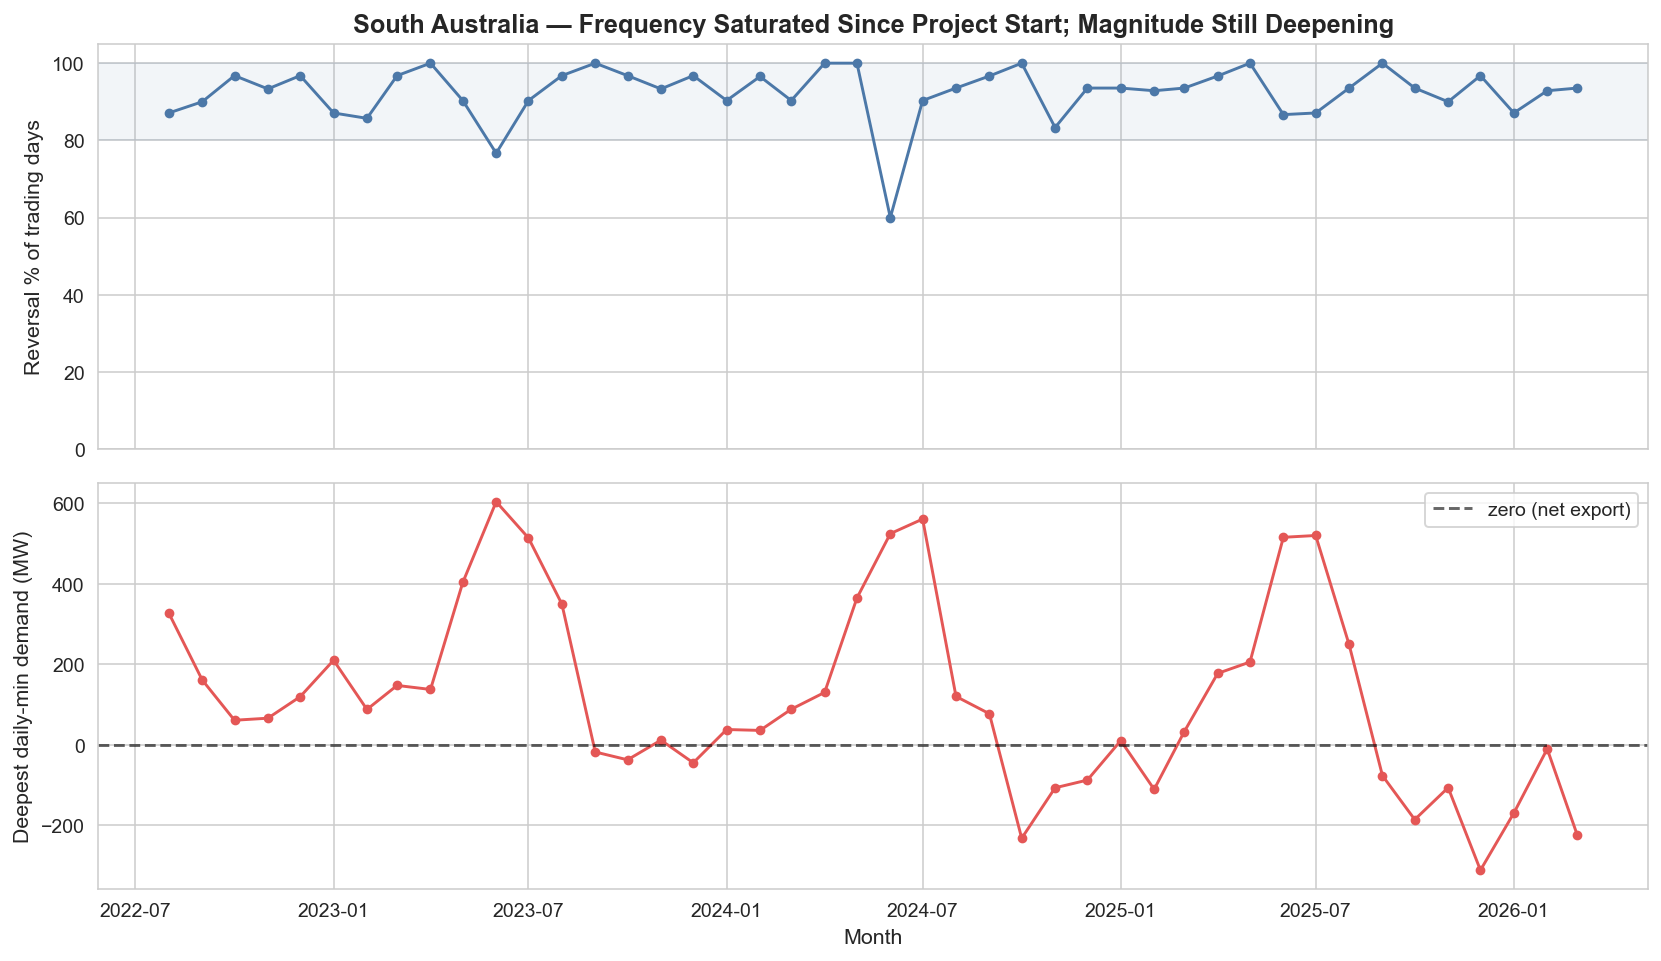

In [4]:
# Two-panel: frequency (top, saturated) + magnitude (bottom, deepening)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(sa.month, sa.reversal_pct, marker='o', ms=4, color='#4C78A8')
ax1.axhspan(80, 100, color='#4C78A8', alpha=0.07)
ax1.set_ylim(0, 105)
ax1.set_ylabel('Reversal % of trading days')
ax1.set_title('South Australia — Frequency Saturated Since Project Start; Magnitude Still Deepening')

ax2.plot(sa.month, sa.deepest_min_demand, marker='o', ms=4, color='#E45756')
ax2.axhline(0, ls='--', color='black', alpha=0.6, label='zero (net export)')
ax2.set_ylabel('Deepest daily-min demand (MW)')
ax2.set_xlabel('Month')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_sa_freq_vs_magnitude.png', dpi=140, bbox_inches='tight')
plt.show()

## Finding 2 — The pre-dawn vs midday demand gap has widened 40 % in three years

**The question.** Finding 1 shows SA reverses on most days, but how rapidly is the midday trough deepening? Compare the same two clock hours year-on-year to remove seasonality.

**The analysis.** Per region, regress monthly mean demand at hour 03 (pre-dawn baseload) minus hour 13 (midday BTM-solar peak) on a time index, with month-of-year fixed effects. The slope coefficient is the annualised rate at which the gap is widening.

**The finding.** All five NEM regions show a statistically significant widening gap (each p < 10⁻⁴). South Australia's gap widened from **658 MW (December 2022) to 922 MW (December 2025)** — a 40 % increase in three years. The pre-dawn baseline barely moves (+7 %); the entire widening is the midday trough getting deeper.

In [5]:
panel = pd.read_sql("""
SELECT regionid,
       month,
       h03_mean,
       h13_mean,
       gap_h03_minus_h13,
       ratio_h13_over_h03
FROM analytics.v_demand_h03_h13_panel
ORDER BY regionid, month;
""", engine, parse_dates=['month'])

panel['month_num'] = panel.month.dt.month
panel['time_idx']  = (panel.month.dt.year - 2022) * 12 + panel.month.dt.month  # 1-indexed month counter (2022-01 = 1)
panel.head()

,regionid,month,h03_mean,h13_mean,gap_h03_minus_h13,ratio_h13_over_h03,month_num,time_idx
0,NSW1,2022-08-01,6875.693575,7031.509812,-155.816237,1.022662,8,8
1,NSW1,2022-09-01,6500.191556,6448.162056,52.029500,0.991996,9,9
2,NSW1,2022-10-01,6134.474113,6363.734355,-229.260242,1.037372,10,10
3,NSW1,2022-11-01,6020.007667,5613.991306,406.016361,0.932556,11,11
4,NSW1,2022-12-01,6024.553548,5957.569812,66.983737,0.988882,12,12


In [6]:
# OLS per region: gap_h03_minus_h13 ~ time_idx + C(month_num)
rows = []
for r in REGION_ORDER:
    d = panel[panel.regionid == r].dropna(subset=['gap_h03_minus_h13'])
    fit = smf.ols('gap_h03_minus_h13 ~ time_idx + C(month_num)', data=d).fit()
    rows.append({
        'region':         r,
        'slope_MW_per_mo': fit.params['time_idx'],
        'p_value':         fit.pvalues['time_idx'],
        'annualised_MW':   fit.params['time_idx'] * 12,
        'r_squared':       fit.rsquared,
        'n_obs':           int(fit.nobs),
    })
ols_df = pd.DataFrame(rows).set_index('region')
ols_df.style.format({
    'slope_MW_per_mo': '{:+.2f}',
    'p_value':         '{:.4f}',
    'annualised_MW':   '{:+.1f}',
    'r_squared':       '{:.3f}',
})

,slope_MW_per_mo,p_value,annualised_MW,r_squared,n_obs
region,,,,,
SA1,+7.47,0.0000,+89.7,0.870,44
VIC1,+15.48,0.0000,+185.7,0.907,44
NSW1,+19.75,0.0000,+237.0,0.790,44
QLD1,+12.61,0.0000,+151.4,0.859,44
TAS1,+1.57,0.0000,+18.9,0.930,44


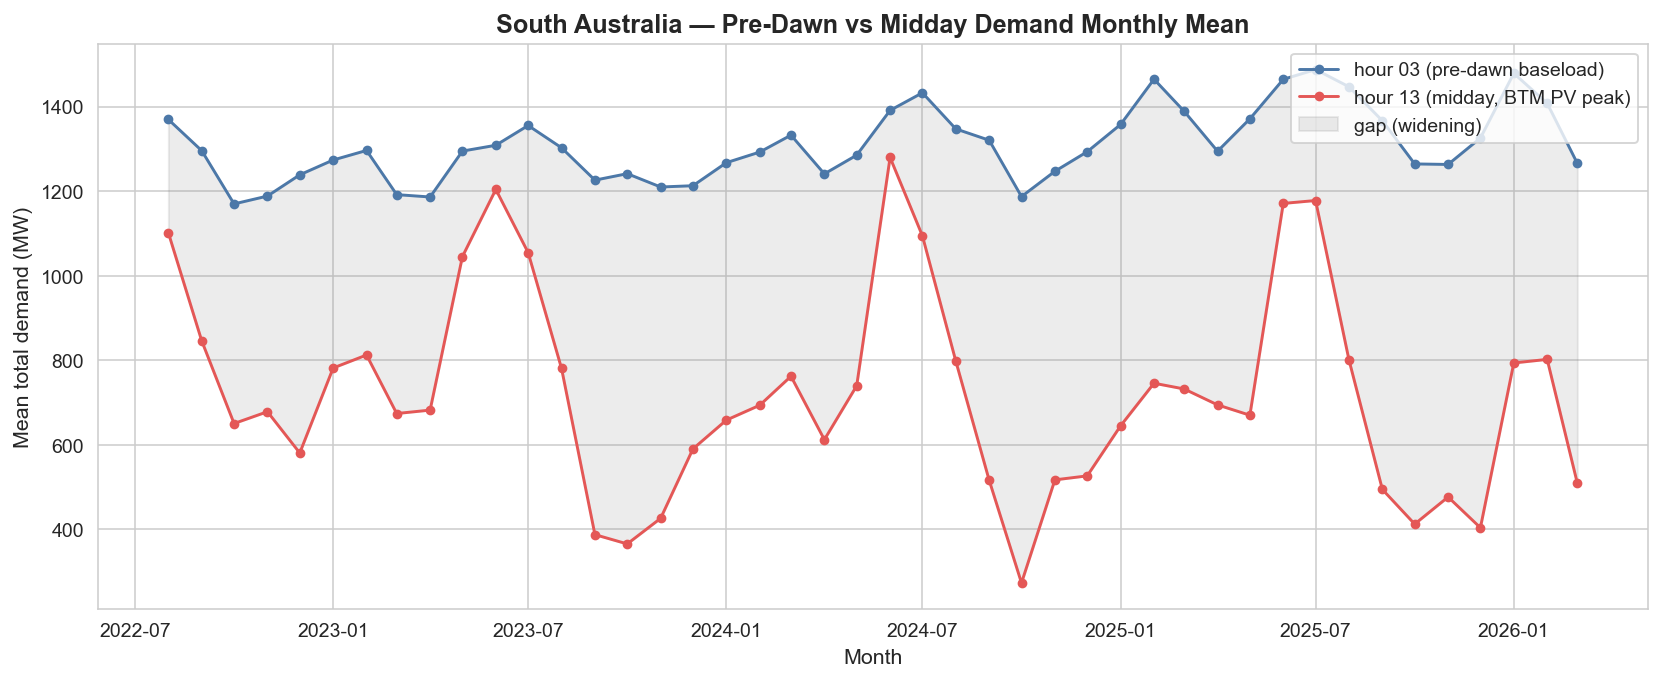

In [7]:
# Hero chart for Finding 2 — SA pre-dawn vs midday demand (the diverging fan)
sa_p = panel[panel.regionid == 'SA1']
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sa_p.month, sa_p.h03_mean, marker='o', ms=4,
        label='hour 03 (pre-dawn baseload)', color='#4C78A8')
ax.plot(sa_p.month, sa_p.h13_mean, marker='o', ms=4,
        label='hour 13 (midday, BTM PV peak)', color='#E45756')
ax.fill_between(sa_p.month, sa_p.h03_mean, sa_p.h13_mean,
                where=(sa_p.h03_mean > sa_p.h13_mean),
                alpha=0.15, color='grey', label='gap (widening)')
ax.set_title('South Australia — Pre-Dawn vs Midday Demand Monthly Mean')
ax.set_ylabel('Mean total demand (MW)')
ax.set_xlabel('Month')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_sa_h03_vs_h13.png', dpi=140, bbox_inches='tight')
plt.show()

In [8]:
# Match-month YoY snapshot — December h13 across years 
dec = panel[(panel.regionid == 'SA1') & (panel.month_num == 12)].copy()
dec['year'] = dec.month.dt.year
dec[['year', 'h03_mean', 'h13_mean', 'gap_h03_minus_h13', 'ratio_h13_over_h03']].set_index('year')

,h03_mean,h13_mean,gap_h03_minus_h13,ratio_h13_over_h03
year,,,,
2022,1238.764301,580.633145,658.131156,0.468720
2023,1212.985511,590.294382,622.691129,0.486646
2024,1293.452097,526.466909,766.985188,0.407025
2025,1325.824355,403.736048,922.088306,0.304517


## Finding 3 — Cross-region reversal frequency mirrors rooftop-PV penetration

**The question.** If the reversal is genuinely solar-driven, it should appear first and deepest in the region with the highest rooftop-PV penetration, and later (and shallower) in regions with lower penetration.

**The analysis.** Plot monthly reversal frequency for all five NEM regions on the same axes; check whether the rank order matches household-rooftop-PV penetration (SA > QLD > VIC > NSW).

**The finding.** The four BTM-solar mainland regions line up cleanly in the expected order:

| Region | Rooftop penetration | Mean reversal freq |
|--------|---------------------|--------------------|
| SA     | ~45 %               | 92 %               |
| QLD    | ~40 %               | 71 %               |
| VIC    | ~30 %               | 58 %               |
| NSW    | ~25 %               | 56 %               |

Tasmania looks like an exception (reversal climbed from 16 % in 2022-08 to 74 % by 2025-12 despite low rooftop PV). That is not anomaly — it is a *separate* phenomenon driven by hydro dispatch, not rooftop solar. Three independent tests in `02_reversal_classifier.ipynb` (Findings 4, 6, 7) all isolate TAS as non-solar; treat it as a sub-finding (1B below), not the tail of the rooftop ranking.

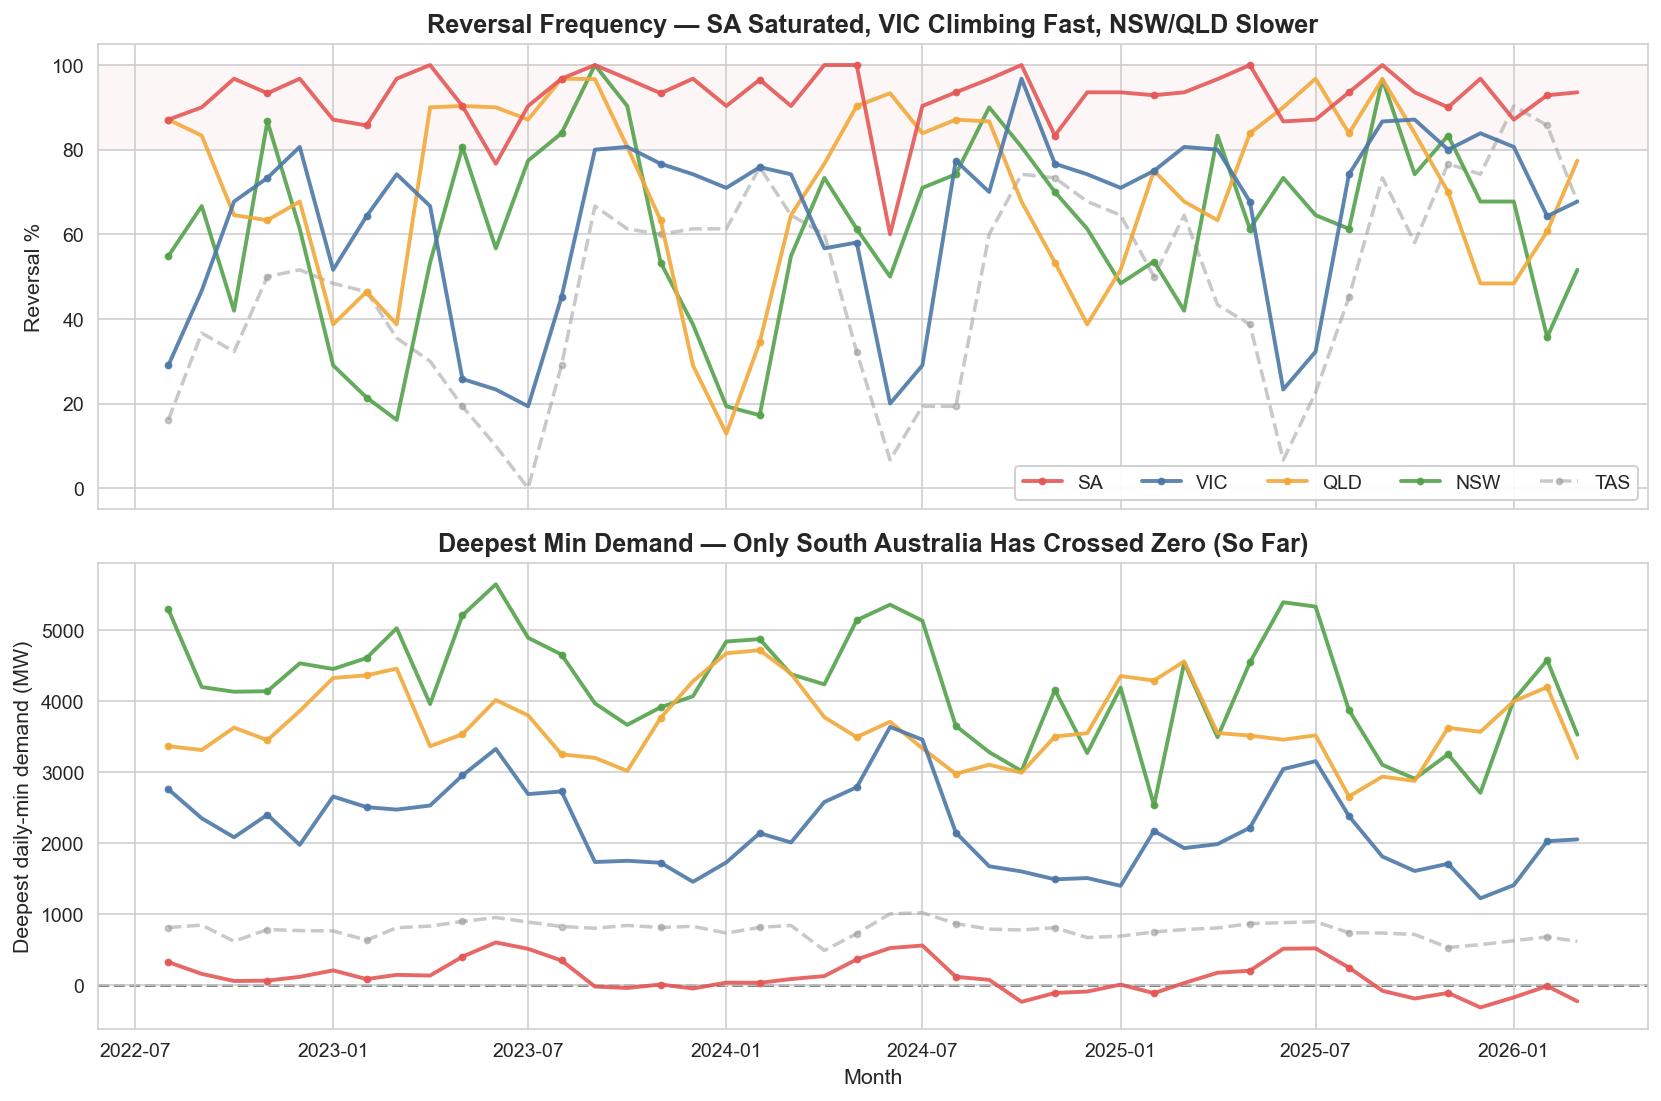

In [9]:
all_rev = pd.read_sql("""
SELECT regionid, month, reversal_pct, deepest_min_demand, n_neg_demand_days
FROM analytics.v_monthly_reversal_rate
ORDER BY regionid, month;
""", engine, parse_dates=['month'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot order: TAS first (background), BTM-PV regions in low->high penetration,
# SA last so it ends up on top in the foreground.
PLOT_ORDER = ['TAS1', 'NSW1', 'QLD1', 'VIC1', 'SA1']

# SA red saturation band on the top chart (very faint, just a story anchor).
ax1.axhspan(80, 100, color='#E45756', alpha=0.05, zorder=0)

for r in PLOT_ORDER:
    d = all_rev[all_rev.regionid == r]
    is_tas = (r == 'TAS1')
    style = dict(
        color=REGION_COLORS[r],
        lw=1.8 if is_tas else 2.0,
        linestyle='--' if is_tas else '-',
        alpha=0.55 if is_tas else 0.9,
        marker='o',
        ms=3,
        markevery=3,
    )
    ax1.plot(d.month, d.reversal_pct, label=REGION_SHORT[r], **style)
    ax2.plot(d.month, d.deepest_min_demand, label=REGION_SHORT[r], **style)

# Reverse legend handles so SA appears first (matches the penetration-order narrative).
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[::-1], labels[::-1], loc='lower right', ncol=5, framealpha=0.92)

ax1.set_ylim(-5, 105)
ax1.set_ylabel('Reversal %')
ax1.set_title('Reversal Frequency — SA Saturated, VIC Climbing Fast, NSW/QLD Slower')

ax2.axhline(0, ls='--', color='black', alpha=0.5, zorder=0)
ax2.set_ylabel('Deepest daily-min demand (MW)')
ax2.set_xlabel('Month')
ax2.set_title('Deepest Min Demand — Only South Australia Has Crossed Zero (So Far)')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_cross_region_trajectory.png', dpi=140, bbox_inches='tight')
plt.show()

In [10]:
# December YoY snapshot per region
dec_all = all_rev[all_rev.month.dt.month == 12].copy()
dec_all['year'] = dec_all.month.dt.year
dec_pivot = dec_all.pivot(index='year', columns='regionid', values='deepest_min_demand')
dec_pivot[REGION_ORDER].rename(columns=REGION_SHORT)

regionid,SA,VIC,NSW,QLD,TAS
year,,,,,
2022,119.60,1976.53,4530.54,3859.83,770.52
2023,-44.56,1456.40,4066.98,4278.25,830.25
2024,-87.40,1509.69,3268.88,3547.42,672.33
2025,-311.10,1224.77,2708.64,3566.30,572.64


### Sub-finding 1A — South Australia now runs as a net exporter on some days

When SA's midday operational demand crosses zero, the region is no longer consuming the grid's traditional supply — it is *exporting* power. This is the most extreme manifestation of Finding 1's magnitude leg.

- **51 region-days** across the 44-month window had at least one negative-demand 5-min interval — all SA; the other four NEM regions had zero such days.
- The day-of-week distribution skews toward weekends: **21 of 51 events occurred on a Sunday** (vs ~7 expected under uniform), reinforcing the rooftop-PV + low-industrial-load story.
- Events cluster in late spring / summer (October–March) and their monthly frequency rises year-on-year — consistent with Finding 1's magnitude leg.


In [11]:
neg = pd.read_sql("""
SELECT regionid, trading_day, dow, is_weekend, n_neg_demand_intervals
FROM analytics.v_daily_demand_summary
WHERE had_negative_demand = TRUE
ORDER BY trading_day;
""", engine, parse_dates=['trading_day'])

print(f'Total neg-demand region-days: {len(neg)}')
print(f'Affected regions: {neg.regionid.unique().tolist()}')
print()
print('By region × dow (0=Sun, 1=Mon, ..., 6=Sat):')
neg.groupby(['regionid', 'dow']).size().unstack(fill_value=0)

Total neg-demand region-days: 51
Affected regions: ['SA1']

By region × dow (0=Sun, 1=Mon, ..., 6=Sat):


dow,0,1,2,3,4,5,6
regionid,,,,,,,
SA1,21,3,5,6,4,4,8


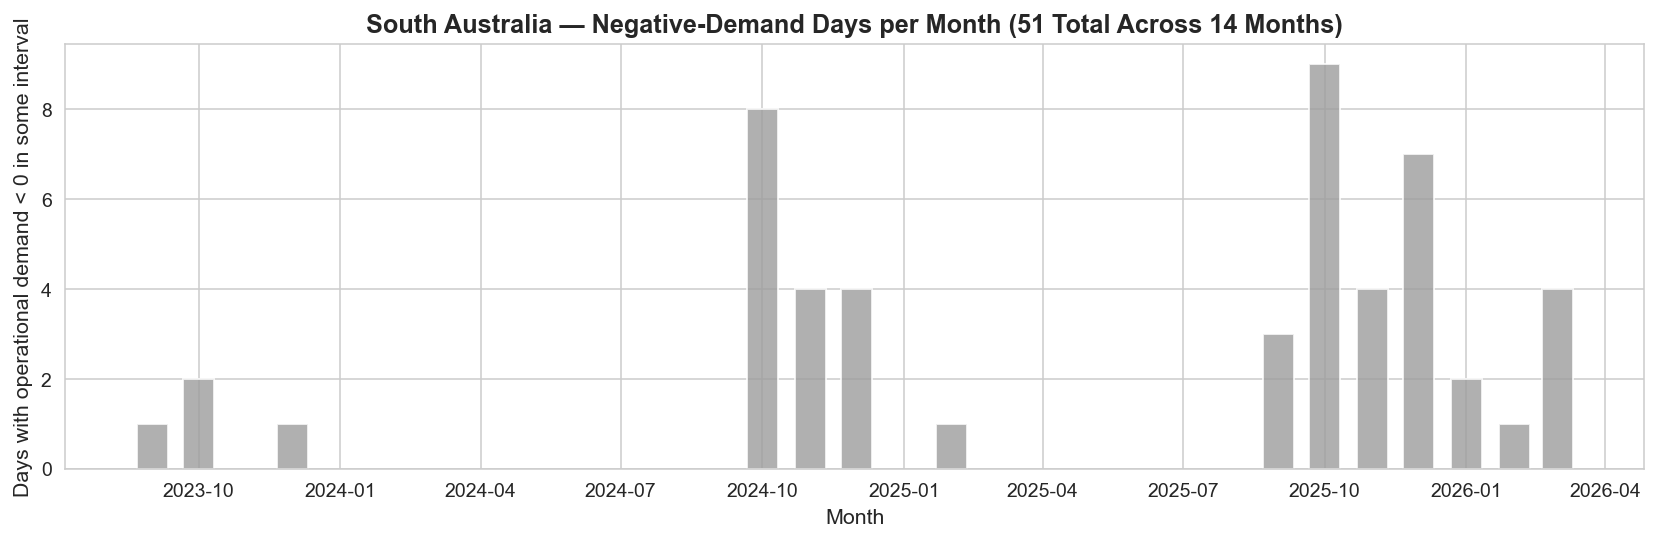

In [12]:
# Monthly distribution of SA neg-demand days
sa_neg = neg[neg.regionid == 'SA1'].copy()
sa_neg['ym'] = sa_neg.trading_day.dt.to_period('M').dt.to_timestamp()
monthly = sa_neg.groupby('ym').size().rename('neg_days').to_frame()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index, monthly.neg_days, width=20, color='#9D9D9D', alpha=0.8)
ax.set_title(f'South Australia — Negative-Demand Days per Month ({len(sa_neg)} Total Across {sa_neg.ym.nunique()} Months)')
ax.set_ylabel('Days with operational demand < 0 in some interval')
ax.set_xlabel('Month')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sub_sa_neg_demand_days.png', dpi=140, bbox_inches='tight')
plt.show()

### Sub-finding 1B — Tasmania's reversal looks similar but is hydro-driven

Tasmania's reversal frequency climbed from 16 % (2022-08) to 74 % (2025-12) despite very low household rooftop-PV penetration (~10 %). The pattern *looks* similar to the mainland BTM-solar regions on the surface, but the mechanism is different: Hydro Tasmania appears to be storing water overnight and drawing down its reservoirs at midday, which compresses operational demand the same way rooftop PV does in the other regions — but for completely different physical reasons.

Three independent tests in `02_reversal_classifier.ipynb` confirm Tasmania behaves differently from the four BTM-solar regions:

- **Finding 4 (rooftop-flow OLS):** TAS's rooftop coefficient sign-flips to *positive* once secular trend is controlled for.
- **Finding 6 (weather decoupling):** TAS is the only region where weather explains max demand better than min demand — the opposite of the BTM-PV signature.
- **Finding 7 (negative-pricing odds):** TAS's reversal-day OR is 0.99 — no co-occurrence with negative pricing, unlike OR ≈ 5 in BTM-solar regions.


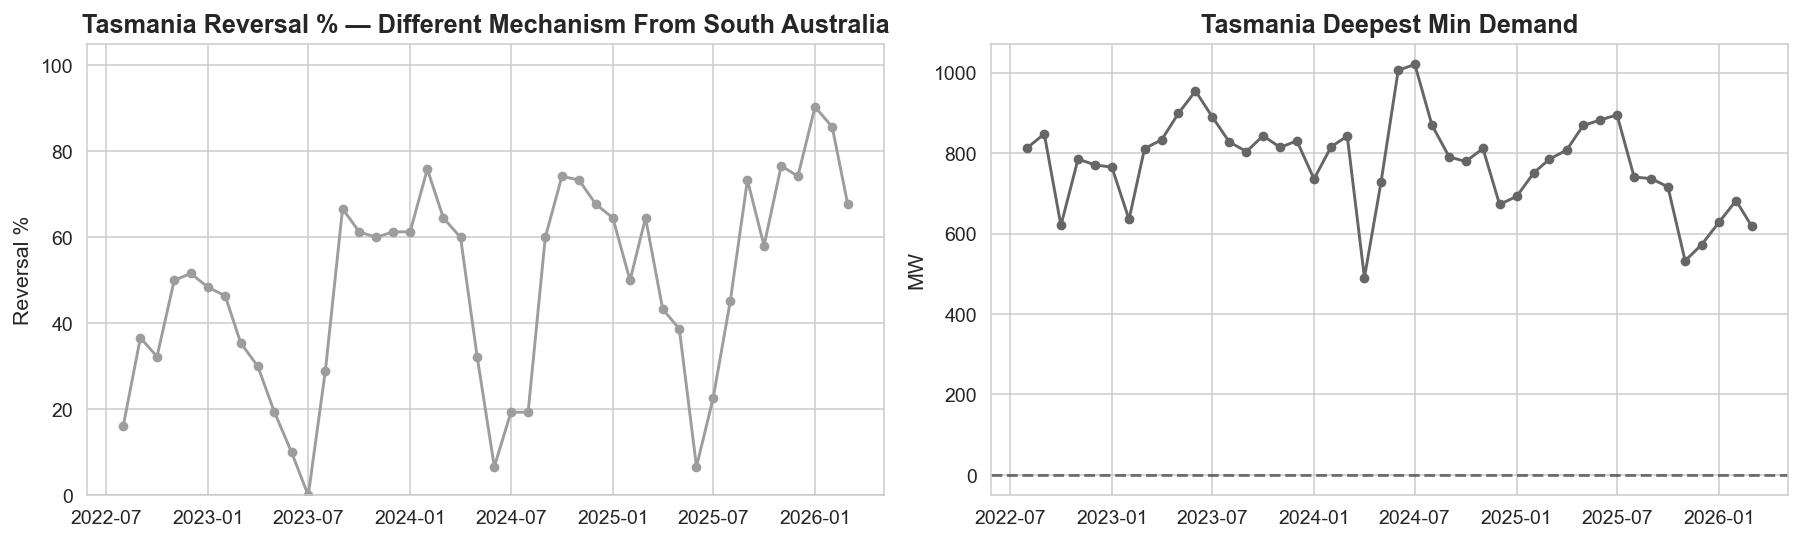

In [13]:
tas = all_rev[all_rev.regionid == 'TAS1']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(tas.month, tas.reversal_pct, marker='o', ms=4, color='#9D9D9D')
ax1.set_title('Tasmania Reversal % — Different Mechanism From South Australia')
ax1.set_ylim(0, 105)
ax1.set_ylabel('Reversal %')
ax2.plot(tas.month, tas.deepest_min_demand, marker='o', ms=4, color='#666666')
ax2.set_title('Tasmania Deepest Min Demand')
ax2.set_ylabel('MW')
ax2.axhline(0, ls='--', color='black', alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sub_tas_anomaly.png', dpi=140, bbox_inches='tight')
plt.show()

## Findings summary

This notebook locks **Findings 1–3** (descriptive evidence). Findings 4–8 (mechanism + ML) are in `02_reversal_classifier.ipynb`.

| # | Finding | Headline number |
|---|---------|-----------------|
| 1 | SA midday reversal near-universal | mean 92 %, range 60–100 %; Dec h13 581 → 404 MW (−30 %) over 3 yrs |
| 2 | h03 vs h13 gap widening | All 5 regions p<10⁻⁴; SA +90 MW/yr; gap 658 → 922 MW (Dec 2022 → Dec 2025) |
| 3 | Cross-region reversal mirrors PV penetration | SA 92 / QLD 71 / VIC 58 / NSW 56 / TAS 48 % (TAS = sub-finding 1B, hydro) |

All three Findings clear their pre-registered acceptance thresholds (see [docs/METHODOLOGY.md](../docs/METHODOLOGY.md)).

Continue to [`02_reversal_classifier.ipynb`](./02_reversal_classifier.ipynb) for mechanism attribution (Findings 4–7) and the 24h-ahead ML classifier (Finding 8).
